
<div style="display:flex;justify-content:flex-start;margin-bottom:14px;">
    <img src="https://github.com/dipsikha-devi/ciroh-devcon26/raw/main/fimeval/Images/DevCon26_logo_small-2-scaled.png" alt="CIROH DevCon 2026"/>
</div>



# **FIMeval v1.1: FIM Evaluation Mapping Prediction Evaluation Framework**
</h1>
  The accuracy of the flood inundation mapping (FIM) is critical for model development and disaster preparedness. The evaluation of flood maps from different sources using geospatial platforms can be tedious and requires repeated processing and analysis for each map. These preprocessing steps includes extracting the correct flood extent, assigning the same projection system to all the maps, categorizing the maps as binary flood maps, removal of permanent water bodies etc. This manual data processing is cumbersome and prone to human error. To address these issues, we developed Flood Inundation Mapping Prediction Evaluation Framework (FIMeval), a python-based FIM evaluation framework capable of automatically evaluating flood maps from different sources. FIMeval takes the advantage of comparing multiple target datasets with large benchmark datasets. It includes an option to incorporate permanent waterbodies as non-flood pixels with a user input file or pre-set dataset. In addition to traditional evaluation metrics, it can also compare the number of buildings inundated using a user input file or a pre-set dataset.

  ### **Methodology**
  The detailed methodology is described in-

  Devi, D., Dhital, S., Munasinghe, D., Cohen, S., Baruah, A., Chen, Y., Tian,D & Pruitt, C. (2025). A framework for the evaluation of flood inundation predictions over extensive benchmark databases. Environmental Modelling & Software, 106786.
  "https://www.sciencedirect.com/science/article/pii/S1364815225004700"

  This notebook is a step-by-step guide to evaluating Flood Inundation Maps using
  <code style="background:#1e3a5f;color:#00d4ff;padding:2px 8px;border-radius:4px;">FIMeval</code> and
  <code style="background:#1e3a5f;color:#f59e0b;padding:2px 8px;border-radius:4px;">FIMbench</code>.
</p>

<div align="center">
  <img src="https://github.com/dipsikha-devi/ciroh-devcon26/raw/main/fimeval/Images/FIMbench_FIMeval.png" alt="FC1" width="100%">
  <p style="margin-top: 10px; font-weight: bold; color: #94a3b8; font-family: 'Segoe UI', sans-serif;">
    Figure 1: Architecture of FIMbench-FIMeval
  </p>
</div>


##  **0. Notebook Steps**

| Step | Section | Description |
|------|---------|-------------|
| 1 | Install | Install `fimeval` via `uv`|
| 2 | Download FIMs | Fetch test rasters from GitHub |
| 3 | Query Benchmarks | Find matching benchmarks with `benchFIMquery()` |
| 4 | Evaluate | Compute confusion matrices with `EvaluateFIM()` |
| 5 | Visualize | Contingency maps, metric plots, building footprints |
| 6 | Bootstrap | Statistical sampling for uncertainty quantification |
| 7 | Multi-Area | Evaluate across multiple geographic regions |


---
## **1. Installation & Setup**

### 1.1 Install the package


In [ ]:
!pip install uv
!uv pip install fimeval==0.1.64

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 53.2 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 158 packages in 1.22s
Prepared 13 packages in 4.97s
Uninstalled 1 package in 39ms
Installed 13 packages in 334ms
 + async-lru==2.3.0
 + boto3==1.43.6
 + botocore==1.43.6
 + fimeval==0.1.64
 + jedi==0.20.0
 + jmespath==1.1.0
 + json5==0.14.0
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.7
 + jupyterlab-server==2.28.0
 + kaleido==0.2.1
 - notebook==6.5.7
 + notebook==7.5.6
 + s3transfer==0.17.0


### 1.2 Suppress Warnings

In [ ]:
# @title
import warnings
import logging
import os

# Suppress all Python warnings
warnings.filterwarnings("ignore")

# Suppress all logging below ERROR level
logging.disable(logging.WARNING)

# Suppress GDAL/rasterio C-level warnings
os.environ["CPL_LOG"] = "/dev/null"
os.environ["GDAL_DATA"] = ""
os.environ["CPL_DEBUG"] = "OFF"
os.environ["CPL_LOGERROR"] = "OFF"

# Suppress specific libraries
for logger_name in logging.root.manager.loggerDict:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

### 1.3 Import fimeval

In [ ]:
import fimeval as fe

---
## **2. Download Sample FIMs**

<div
</b>  Benchmark FIM (B-FIM) and Model Predicted FIM (M-FIM) for Oct 14 2016 flood event, HUC8 <code>03020201</code>.There are two model predicted FIM generated using Surrogate Modelling and using Office of Weather Prediction (OWP) Height Above Nearest Drainage (HAND) FIM. These maps will be downloaded from GitHub.
</div>

| Files | Type | Method Used For Generation |
|------|-------------|--------|
| `SMprediction_hand_NWM_20161014150000_03020201_inundation.tif` |  M-FIM 1 | Surrogate Model FIM |
| `hand_NWM_20161014150000_03020201_inundation.tif` | M-FIM2 | OWP HAND FIM |

In [ ]:
!mkdir -p test-FIMs

# Note the change from /blob/ to /raw/ in the URLs below
!wget -q --show-progress -O test-FIMs/SMprediction_hand_NWM_20161014150000_03020201_inundation.tif \
  https://github.com/sdmlua/ciroh-devcon26/raw/main/fimeval/test-FIMs/SMprediction_hand_NWM_20161014150000_03020201_inundation.tif

!wget -q --show-progress -O test-FIMs/hand_NWM_20161014150000_03020201_inundation.tif \
  https://github.com/sdmlua/ciroh-devcon26/raw/main/fimeval/test-FIMs/hand_NWM_20161014150000_03020201_inundation.tif

test-FIMs/SMpredict 100%[===================>] 515.09K  --.-KB/s    in 0.02s   
test-FIMs/hand_NWM_ 100%[===================>] 341.29K  --.-KB/s    in 0.02s   


---
## **3. Query the Benchmark Catalog**
This supports multiple combinations of filters:<br>
1) Direct filename download (no AOI/dates).<br>
2) AOI-only search (raster or boundary), optional overlap stats.<br>
3) AOI + exact date.<br>
4) AOI + date range (with optional download).<br>

### `benchFIMquery()` parameters

| Parameters | Requirement | Description |
|-----------|----------|-------------|
| `raster_path` | optional | e.g M-FIM path — defines AOI automatically |
| `boundary_path` | optional | Vector shapefile for AOI    (can be used with or without raster) |
| `huc8` | optional | 8-digit HUC basin ID (mainly for US basins) |
| `event_date` | optional | Exact date `"YYYY-MM-DD"` (optionally with hour)|
| `start_date` / `end_date` | optional | Date range |
| `file_name` | optional | Direct benchmark filename from the catalog |
| `tier` | optional | `"HWM"`, `"Tier1"` … `"Tier4"` |
| `area` | optional | If "True" and AOI given, return overlap % and area km² vs benchmark AOI |
| `download` | optional | If "True" download matched rasters/GPKGs to ``out_dir`` |
| `out_dir` | optional | If `download`=True, save all the files in the directory |

### 3.1 Search for overlapping benchmarks

In [ ]:
# Using boundary/raster inputs
raster_path = "/content/test-FIMs/SMprediction_hand_NWM_20161014150000_03020201_inundation.tif"
boundary_path = "path/to/boundary"
response = fe.benchFIMquery(
        raster_path=raster_path,
        # boundary_path=boundary_path,
        # huc8="03020201",  # Example HUC8 ID: "03020201"
        # event_date = "2017-05-01",
        # start_date = "2016-01-10",
        # end_date = "2016-12-20",
        # file_name = "BLE_10_0m_500_985556W300139N_BM.tif",
        # tier = "tier4",  # Example tier filter: "HWM", "Tier1", "Tier2", etc.
        area=True,  # Default is false; if True, returns overlap stats
        # download=True,
        # out_dir="../downloads/",  # required if download=True
    )
print(response)

Following are the available benchmark data for your given location:
Total benchmark FIMs found: 3  (HWM: 2, Tier_2: 1)
Data Tier: HWM
Benchmark FIM date: 2016-09-28 to 2016-10-09
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20160928_20161009_780051W352232N_BM.tif
Overlap with respect to benchmark FIM: 58.0% / 142.80 km²

Data Tier: HWM
Benchmark FIM date: 2018-08-31 to 2018-09-18
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20180831_20180918_782136W352113N_BM.tif
Overlap with respect to benchmark FIM: 18.5% / 97.83 km²

Data Tier: Tier_2
Benchmark FIM date: 2016-10-14T15
Spatial Resolution: 3.1m
Raster Filename in DB: PSS_3_1m_20161014T150759_780013W352043N_BM.tif
Overlap with respect to benchmark FIM: 56.9% / 131.11 km²


### 3.2 Mount Google Drive *(optional)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 3.3 Download the chosen benchmark

In [ ]:

fe.benchFIMquery(
        # raster_path=raster_path,
        # boundary_path=boundary_path,
        # huc8="03020201",  # Example HUC8 ID: "03020201"
        # event_date = "2017-05-01",
        # start_date = "2016-10-10",
        # end_date = "2026-10-20",
        file_name = "PSS_3_1m_20161014T150759_780013W352043N_BM.tif",
        # tier = "tier4",  # Example tier filter: "HWM", "Tier1", "Tier2", etc.
        # area=True,  # Default is false; if True, returns overlap stats
        download=True,
        out_dir="./test-FIMs",  # required if download=True
    )

Following are the available benchmark data for your given location:
Total benchmark FIMs found: 3  (HWM: 2, Tier_2: 1)
Data Tier: HWM
Benchmark FIM date: 2016-09-28 to 2016-10-09
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20160928_20161009_780051W352232N_BM.tif

Data Tier: HWM
Benchmark FIM date: 2018-08-31 to 2018-09-18
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20180831_20180918_782136W352113N_BM.tif

Data Tier: Tier_2
Benchmark FIM date: 2016-10-14T15
Spatial Resolution: 3.1m
Raster Filename in DB: PSS_3_1m_20161014T150759_780013W352043N_BM.tif

Downloaded 3 intersecting benchmark record(s) to 'test-FIM1'.

---
## **4. Evaluate the Model FIM Against Benchmark**

| # | Method | Label |
|---|---|---|
| 1 | Smallest Extent | `"smallest_extent"` |
| 2 | Convex Hull | `"convex_hull"` |
| 3 | AOI | `"AOI"` |
| 4 | Intersected Extent | `"intersected_extent"` |
| 5 | Bootstrap | `"bootstrap"` |

### 4.1 Configure paths and method

In [ ]:
Main_dir = "/content/test-FIMs"  # This is the main directory where all the cases are stored.

PWD_dir = "./path/to/PWB"

output_dir = "./fimeval-output"  # This is the output directory where the results will be saved

target_crs = "EPSG:5070"  # Target CRS for reprojecting the FIMs, need to be in EPSG code of Projected CRS. If it is within CONUS it will automatically take EPSG:5070
target_resolution = 10  # This will be in meters, if it passes the FIMS will be resampled to this resolution else, it will find the coarser resolution among all FIMS for this case and use that to resample!
building_footprint = "path/to/building_footprint.shp"  # If user is working with user defined building footprint shapefile

# If user is working with user defined shapefile
AOI = "path/to/aoi.shp"  # This shapefile should be in projected CRS, if not, it will be reprojected to the target CRS
method = "intersected_extent"  # "smallest_extent", "convex_hull", "AOI", "intersected_extent", "bootstrap"

### 4.2 Run the evaluation

In [ ]:
# Run Evaluation
fe.EvaluateFIM(
    Main_dir,
    method_name=method,
    output_dir=output_dir,
    # PWB_dir=None,
    # shapefile_dir=None,     #If you are working with you own AOI for this evaluation, for method_name= AOI only
    # target_crs=None,        # If user have some specific CRS preference, send the EPSG code.
    # target_resolution=None,   #If user doesnot send any, it will use the coarser among model and benchmark FIMs from the main directory
)

Defaulting to CONUS CRS: EPSG:5070, Reprojecting.


Using coarsest resolution: X=8.535663986434926, Y=8.535663986434926
**Flood Inundation Evaluation of test-FIMs**
**intersected_extent is processing**


PWB Extraction complete.
Benchmark saved: ./fimeval-output/test-FIMs/intersected_extent/MaskedFIMwithBoundary/PSS_3_1m_20161014T150759_780013W352043N_BM_clipped.tif  unique values: [  0   2 255]


Confusion raster unique values: [0 1 2 3 4 5]


Confusion raster unique values: [0 1 2 3 4 5]
Evaluation metrics saved to ./fimeval-output/test-FIMs/intersected_extent/EvaluationMetrics/EvaluationMetrics.csv


         Metrics  hand_NWM_20161014150000_03020201_inundation  SMprediction_hand_NWM_20161014150000_03020201_inundation
      CSI_values                                        0.594                                                     0.608
       TN_values                                  1481583.000                                               1469059.000
       FP_values                                    40905.000                                                 53429.000
       FN_values                                   209780.000                                                193416.000
       TP_values                                   367301.000                                                383665.000
      TPR_values                                        0.636                                                     0.66

---
## **5. Visualize Results**


</div>

| Function | Output |
|----------|--------|
| `PrintContingencyMap()` | Display the confusion raster |
| `PlotEvaluationMetrics()` | Display the metrics |
| `EvaluationWithBuildingFootprint()` | Display the building hit counts |


****** Printing Contingency Map for ./fimeval-output/test-FIMs/smallest_extent/ContingencyMaps/ContingencyMAP_hand_NWM_20161014150000_03020201_inundation.tif ******


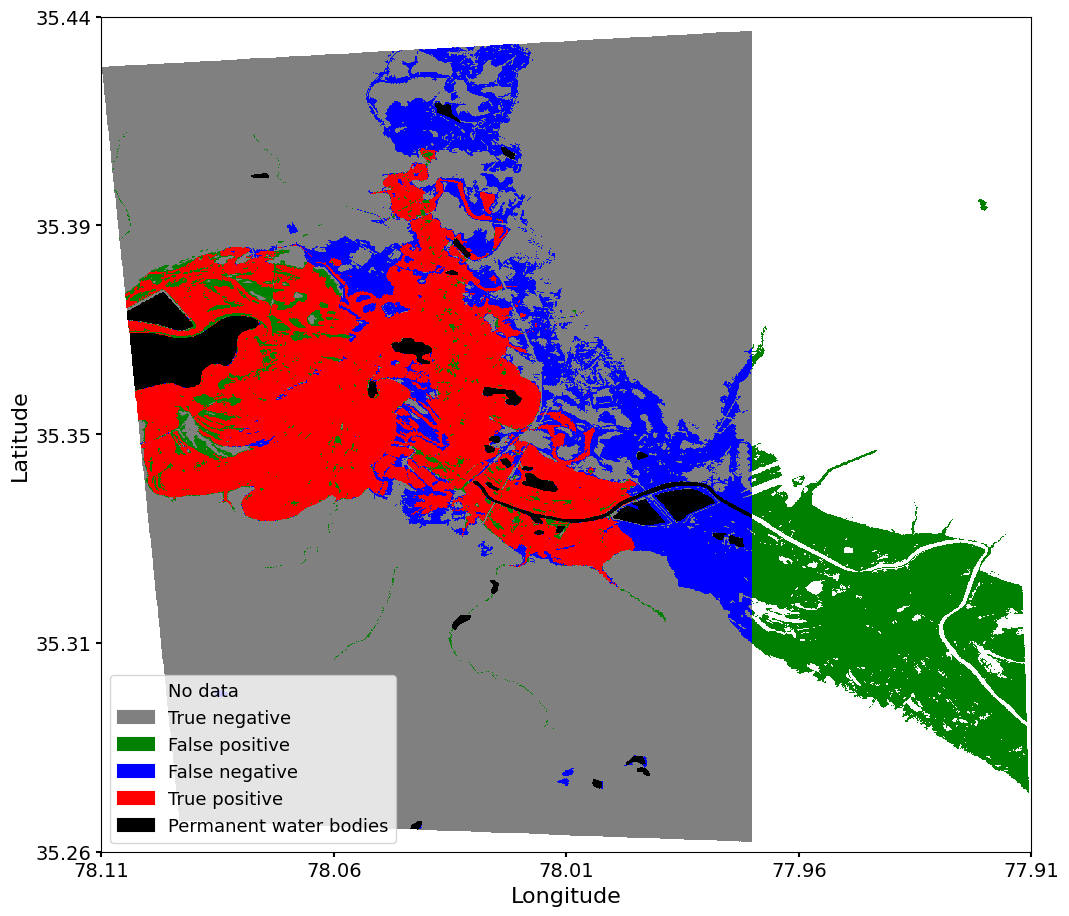

****** Printing Contingency Map for ./fimeval-output/test-FIMs/smallest_extent/ContingencyMaps/ContingencyMAP_SMprediction_hand_NWM_20161014150000_03020201_inundation.tif ******


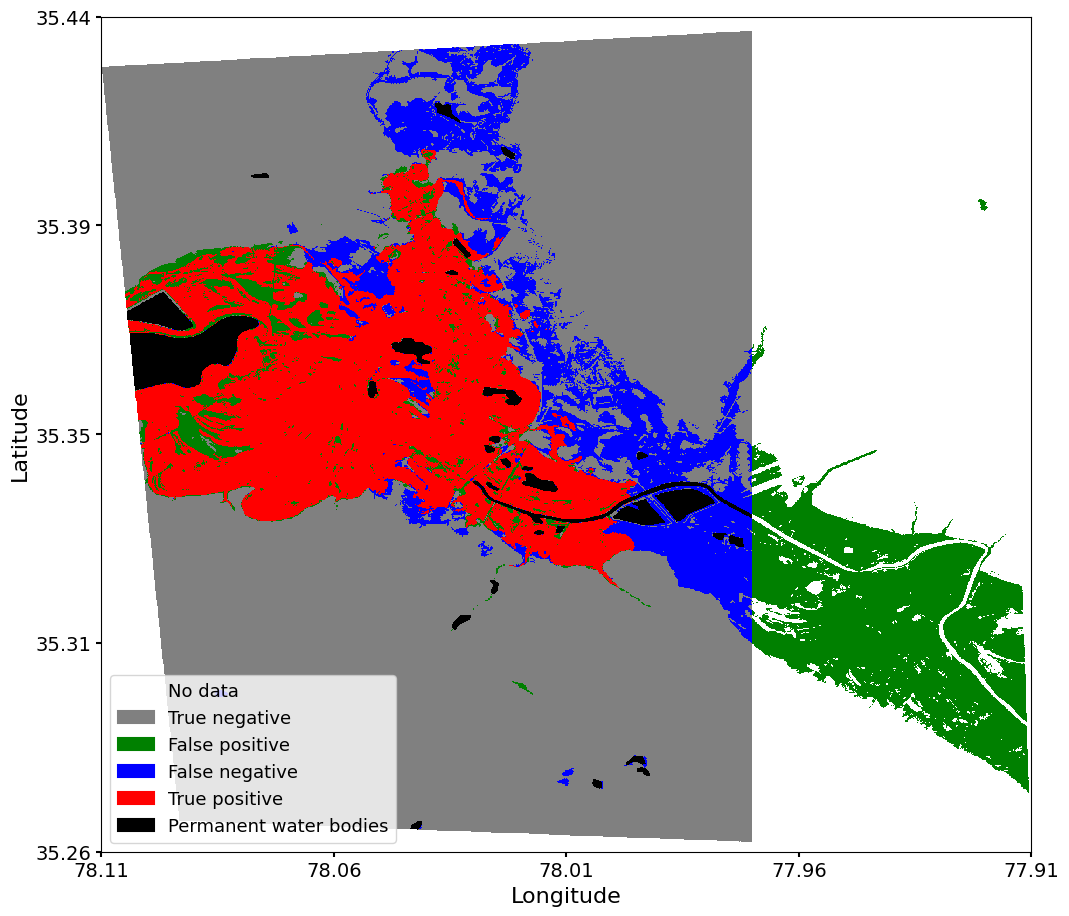

PNG saved at: ./fimeval-output/test-FIMs/smallest_extent/FinalPlots/EvaluationMetrics_hand_NWM_20161014150000_03020201_inundation.png


PNG saved at: ./fimeval-output/test-FIMs/smallest_extent/FinalPlots/EvaluationMetrics_SMprediction_hand_NWM_20161014150000_03020201_inundation.png


In [ ]:
# Print the Maps
# Once the FIM evaluation is done, print the contingency map
fe.PrintContingencyMap(Main_dir, method, output_dir)

# Plot the evaluation metrics after the FIM evaluation
fe.PlotEvaluationMetrics(Main_dir, method, output_dir)

### 5.2 Building footprint evaluation
Calculate the building hit using the function EvaluationWithBuildingFootprint

EvaluationWithBuildingFootprint(
    Main_dir,
    method,
    output_dir,
    # building_footprint = building_footprint
    # If None, building footprints are automatically retrieved
    # shapefile_dir = AOI
    # Required only when using user-defined AOI)




In [ ]:
# Evaluation using Building Footprints

# FIM Evaluation with Building Footprint (by default, it uses the Microsoft Building Footprint dataset retrieved using ArcGIS REST API)
# It will use the evaluation boundary to retrieve the building footprints
fe.EvaluationWithBuildingFootprint(
    Main_dir,
    method,
    output_dir,
    # building_footprint=building_footprint, #If None, it will pull
    # shapefile_dir=AOI   #if user is using AOI, need to give the path
)

Querying https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/MSBFP2/FeatureServer/0...
Clipping 18387 features to boundary...

SUCCESS: Saved 15704 buildings to:
  fimeval-output/test-FIMs/intersected_extent/BuildingFootprint/building_footprints.gpkg
reproject building_gdf


PNG were saved in : ./fimeval-output/test-FIMs/intersected_extent/FinalPlots/BuildingCounts_SMprediction_hand_NWM_20161014150000_03020201_inundation.png
reproject building_gdf


PNG were saved in : ./fimeval-output/test-FIMs/intersected_extent/FinalPlots/BuildingCounts_hand_NWM_20161014150000_03020201_inundation.png


---
## **6. Bootstrap Evaluation**
Uncertainty quantification — repeated spatial sampling gives a distribution of metric values.


| Sub-method | `sub_method` | `spacing_range` | Best for |
|------------|-------------|-----------------|---------|
| Random | `"random"` | `None` | Unbiased baseline |
| Stratified | `"stratified"` | `None` | Class imbalance |
| Systematic | `"systematic"` | e.g. `(100,1000)` | Spatial coverage |

### 6.1 Run bootstrap

Defaulting to CONUS CRS: EPSG:5070, Reprojecting.


Using coarsest resolution: X=8.535663986434926, Y=8.535663986434926
**Flood Inundation Evaluation of test-FIMs**
**bootstrap is processing**


PWB Extraction complete.
Benchmark saved: ./fimeval-output/test-FIMs/bootstrap/MaskedFIMwithBoundary/PSS_3_1m_20161014T150759_780013W352043N_BM_clipped.tif  unique values: [  0   2 255]


Confusion raster unique values: [0 1 2 3 4 5]


Confusion raster unique values: [0 1 2 3 4 5]
Iter 001 | TP: 79, FP: 10, FN: 53, TN: 340 | CSI: 0.556
Iter 010 | TP: 80, FP: 15, FN: 51, TN: 343 | CSI: 0.548
Boxplot saved as: ./fimeval-output/test-FIMs/bootstrap/Random_Sampling/random_hand_NWM_20161014150000_03020201_inundation.png


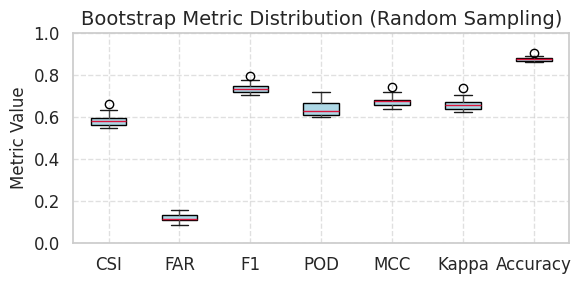

Iter 001 | TP: 85, FP: 13, FN: 47, TN: 337 | CSI: 0.586
Iter 010 | TP: 82, FP: 17, FN: 49, TN: 341 | CSI: 0.554
Boxplot saved as: ./fimeval-output/test-FIMs/bootstrap/Random_Sampling/random_SMprediction_hand_NWM_20161014150000_03020201_inundation.png


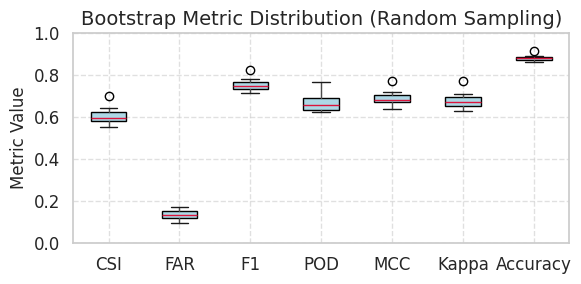

Evaluation metrics saved to ./fimeval-output/test-FIMs/bootstrap/EvaluationMetrics/EvaluationMetrics.csv


         Metrics  hand_NWM_20161014150000_03020201_inundation  SMprediction_hand_NWM_20161014150000_03020201_inundation
      CSI_values                                        0.594                                                     0.608
       TN_values                                  1481583.000                                               1469059.000
       FP_values                                    40905.000                                                 53429.000
       FN_values                                   209780.000                                                193416.000
       TP_values                                   367301.000                                                383665.000
      TPR_values                                        0.636                                                     0.665
      FNR_values                                     

In [ ]:
# Run bootstrap
"""
Run bootstrap-based sampling for flood map evaluation.

Parameters
----------
benchmark_path : Path to benchmark raster.
candidate_paths :  List of candidate raster paths.
confusion_raster_path :  Path to confusion raster.
method : str, default="random"
    Sampling method: "random", "systematic", or "stratified".
n_iterations : int, default=100
    Number of bootstrap iterations.
n_points : int, default=500
    Number of sample points per iteration.
spacing_range : float, optional (only for sytematic. For other methods it should be 'None'. )
    Grid spacing range for systematic sampling.
    For eg.(100,1000).The grid space will randomly change in between 100 and 1000 with each iteration.
seed : int, optional
    Random seed.
save_points : bool, default=False
    Whether to save sampled points.
save_every : int, default=1
    Save points every N iterations.
output_folder : str, optional
    Output directory.
plot_metrics : bool, default=False
    Whether to plot bootstrap metric distributions.
  """
fe.EvaluateFIM(
    Main_dir,
    method_name = 'bootstrap',
    output_dir = output_dir,
    # target_crs=target_crs,
    # target_resolution=target_resolution,
    # shapefile_dir=AOI,
    sub_method="random",  #three submethods- random, stratified and systematic
    spacing_range=None,
    n_iterations=10,
    n_points=500,
    seed=42,
    save_points=True,
    save_every=5,
    plot_metrics=True,
)

---
## **7. Multi-Area Evaluation**

Scale to many regions— one subfolder per area, one <code>benchmark_dict</code>, one call.

**Directory structure:**
```
test-MainDir/
├── area1/   ← M-FIM1
└── area2/   ← M-FIM2
```


### 7.1 Organize files

In [ ]:
# @title
#Organize files
import os
import shutil

# Define the paths
source_dir = 'test-FIMs'
main_folder = '/content/test-MainDir'

# Explicit Mapping: { "Filename" : "Target Subfolder" }
# You can add as many files as you need to this list
file_mapping = {
    "SMprediction_hand_NWM_20161014150000_03020201_inundation.tif": "area1",
    "hand_NWM_20161014150000_03020201_inundation.tif": "area2"
}

def organize_tif_data(source, mapping):
    """
    Copies specific files from the source directory to
    defined subfolders based on the mapping dictionary.
    """
    for file_name, folder_name in mapping.items():
        src_path = os.path.join(source, file_name)
        dest_dir = os.path.join(main_folder, folder_name)
        dest_path = os.path.join(dest_dir, file_name)

        # Ensure the destination subfolder exists
        os.makedirs(dest_dir, exist_ok=True)

        # Check if the source file exists before copying
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
            print(f"Successfully copied: {file_name} -> {folder_name}/")
        else:
            print(f"Error: File not found: {src_path}")

# Run the function
organize_tif_data(source_dir, file_mapping)

Successfully copied: SMprediction_hand_NWM_20161014150000_03020201_inundation.tif -> area1/
Successfully copied: hand_NWM_20161014150000_03020201_inundation.tif -> area2/


In [ ]:
#Finding the right benchmark
response = fe.benchFIMquery(
        raster_path="/content/test-MainDir/area1/SMprediction_hand_NWM_20161014150000_03020201_inundation.tif",
        # boundary_path=boundary_path,
        # huc8="03020201",  # Example HUC8 ID: "03020201"
        # event_date = "2017-05-01",
        # start_date = "2016-10-10",
        # end_date = "2026-10-20",
        # file_name = "BLE_10_0m_500_985556W300139N_BM.tif",
        # tier = "tier4",  # Example tier filter: "HWM", "Tier1", "Tier2", etc.
        # area=True,  # Default is false; if True, returns overlap stats
        # download=True,
        # out_dir="../downloads/",  # required if download=True
    )
print(response)

Following are the available benchmark data for your given location:
Total benchmark FIMs found: 3  (HWM: 2, Tier_2: 1)
Data Tier: HWM
Benchmark FIM date: 2016-09-28 to 2016-10-09
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20160928_20161009_780051W352232N_BM.tif

Data Tier: HWM
Benchmark FIM date: 2018-08-31 to 2018-09-18
Spatial Resolution: 10.0m
Raster Filename in DB: HWM_10_0m_20180831_20180918_782136W352113N_BM.tif

Data Tier: Tier_2
Benchmark FIM date: 2016-10-14T15
Spatial Resolution: 3.1m
Raster Filename in DB: PSS_3_1m_20161014T150759_780013W352043N_BM.tif


### 7.2 Query, build dictionary, and evaluate

In [ ]:
#Prepare the dictionary of case vs right benchmark
benchmark_dict = {
    "area1": "HWM_10_0m_20160928_20161009_780051W352232N_BM.tif",
    "area2": "PSS_3_1m_20161014T150759_780013W352043N_BM.tif"
    }


In [ ]:
#Now Evaluate for every case
new_maindir = "/content/test-MainDir"

fe.EvaluateFIM(
    main_dir=new_maindir,
    method_name = 'AOI',
    output_dir = output_dir,
    benchmark_dict=benchmark_dict
  )

Defaulting to CONUS CRS: EPSG:5070, Reprojecting.
Using coarsest resolution: X=9.568580339884614, Y=9.568580339884614
**Flood Inundation Evaluation of area1**
Auto-detected boundary: /content/test-MainDir/area1/HWM_10_0m_20160928_20161009_780051W352232N_AOI.gpkg
PWB Extraction complete.
Benchmark saved: ./fimeval-output/area1/AOI/MaskedFIMwithBoundary/HWM_10_0m_20160928_20161009_780051W352232N_BM_clipped.tif  unique values: [  0   2 255]
Confusion raster unique values: [0 1 2 3 4 5]
Evaluation metrics saved to ./fimeval-output/area1/AOI/EvaluationMetrics/EvaluationMetrics.csv


         Metrics  SMprediction_hand_NWM_20161014150000_03020201_inundation
      CSI_values                                                     0.412
       TN_values                                               1229715.000
       FP_values                                                217256.000
       FN_values                                                283308.000
       TP_values                        

Defaulting to CONUS CRS: EPSG:5070, Reprojecting.
Using coarsest resolution: X=9.568580339884614, Y=9.568580339884614
**Flood Inundation Evaluation of area1**
**bootstrap is processing**
PWB Extraction complete.
Benchmark saved: ./fimeval-output/area1/bootstrap/MaskedFIMwithBoundary/HWM_10_0m_20160928_20161009_780051W352232N_BM_clipped.tif  unique values: [  0   2 255]
Confusion raster unique values: [0 1 2 3 4 5]
Iter 001 | TP: 90, FP: 5, FN: 62, TN: 327 | CSI: 0.573
Iter 010 | TP: 92, FP: 5, FN: 76, TN: 310 | CSI: 0.532
Boxplot saved as: ./fimeval-output/area1/bootstrap/Random_Sampling/random_SMprediction_hand_NWM_20161014150000_03020201_inundation.png


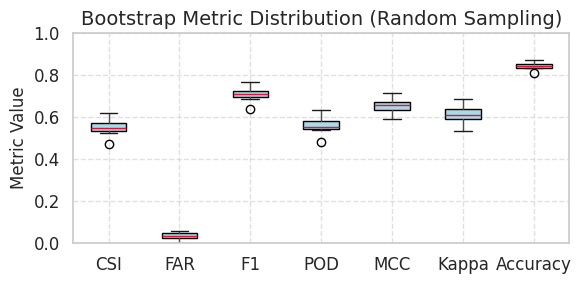

Evaluation metrics saved to ./fimeval-output/area1/bootstrap/EvaluationMetrics/EvaluationMetrics.csv


         Metrics  SMprediction_hand_NWM_20161014150000_03020201_inundation
      CSI_values                                                     0.539
       TN_values                                               1223373.000
       FP_values                                                 16695.000
       FN_values                                                283308.000
       TP_values                                                350488.000
      TPR_values                                                     0.553
      FNR_values                                                     0.447
      Acc_values                                                     0.840
     Prec_values                                                     0.955
      sen_values                                                     0.553
       F1_values                                                     0.7

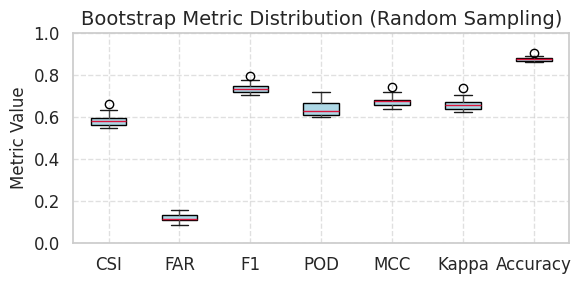

Evaluation metrics saved to ./fimeval-output/area2/bootstrap/EvaluationMetrics/EvaluationMetrics.csv


         Metrics  hand_NWM_20161014150000_03020201_inundation
      CSI_values                                        0.594
       TN_values                                  1481583.000
       FP_values                                    40905.000
       FN_values                                   209780.000
       TP_values                                   367301.000
      TPR_values                                        0.636
      FNR_values                                        0.364
      Acc_values                                        0.881
     Prec_values                                        0.900
      sen_values                                        0.636
       F1_values                                        0.746
      POD_values                                        0.636
      FPR_values                                        0.027
      MCC_values             

In [ ]:
fe.EvaluateFIM(
    main_dir = new_maindir,
    method_name = 'bootstrap',
    output_dir = output_dir,
    benchmark_dict=benchmark_dict,
    # target_crs=target_crs,
    # target_resolution=target_resolution,
    # shapefile_dir=AOI,
    sub_method="random",  #three submethods- random, stratified and systematic
    spacing_range=None,
    n_iterations=10,
    n_points=500,
    seed=42,
    save_points=True,
    save_every=5,
    plot_metrics=True,
)